In [1]:
import pandas as pd

In [3]:
fastaid = pd.read_csv('../../../20251020_interproscan/parsing/SI_original/gh18alldomains_multiperseq_numdomainsannot_SI.csv')
annot = pd.read_csv('all_domains_annotated_deduplicated_cleaned_proteinfprint_withorg_taxidinfo.tsv', sep='\t')
fastaid_annot = fastaid.merge(annot, how='left', left_on='protein_accession', right_on='protein_accession') 
fastaid_annot = fastaid_annot.drop_duplicates(subset=['fastaID'], keep='first')
#fastaid_annot.to_csv('all_domains_annotated_deduplicated_cleaned_proteinfprint_withorg_taxidinfo_fastaID.csv', index=False)

In [4]:
# load header mapping
header_map=pd.read_csv('../data/gh18domIPscan_header_map.txt', dtype=str)
header_map.head()

,id,header
0,0,A0A010YG22|1of1
1,1,A0A011PM39|1of1
2,2,A0A011PXQ4|1of1
3,3,A0A014LJM1|1of1
4,4,A0A014LR51|1of1


In [5]:
fastaid_annot_id = fastaid_annot.merge(header_map, how='left', left_on='fastaID', right_on='header')

clusts96 = pd.read_csv('../output/mmseqs_clustering/gh18domIPscan/gh18domIPscan_mmseqs_clusters_96.0.csv').rename(columns={'cluster': 'cluster96'})
clust293 = pd.read_csv('../output/mmseqs_clustering/gh18domIPscan/gh18domIPscan_mmseqs_clusters_293.0.csv').rename(columns={'cluster': 'cluster293'})
clust162 = pd.read_csv('../output/mmseqs_clustering/gh18domIPscan/gh18domIPscan_mmseqs_clusters_162.0.csv').rename(columns={'cluster': 'cluster162'})
clust473 = pd.read_csv('../output/mmseqs_clustering/gh18domIPscan/gh18domIPscan_mmseqs_clusters_473.0.csv').rename(columns={'cluster': 'cluster473'})

#merge all cluster dataframes and then merge with fastaid_annot_id
clusts = clusts96.merge(clust293, how='left', on='id').merge(clust162, how='left', on='id').merge(clust473, how='left', on='id')
#ensure all id columns are strings
clusts['id'] = clusts['id'].astype(str)

fastaid_annot_id_clusts = fastaid_annot_id.merge(clusts, how='left', left_on='id', right_on='id')
#ensure all values in cluster columns are strings
fastaid_annot_id_clusts['cluster96'] = fastaid_annot_id_clusts['cluster96'].astype(str)
fastaid_annot_id_clusts['cluster293'] = fastaid_annot_id_clusts['cluster293'].astype(str)
fastaid_annot_id_clusts['cluster162'] = fastaid_annot_id_clusts['cluster162'].astype(str)
fastaid_annot_id_clusts['cluster473'] = fastaid_annot_id_clusts['cluster473'].astype(str)
fastaid_annot_id_clusts

,Unnamed: 0,protein_accession,sequence_md5,sequence_length,analysis,signature_accession,signature_description,start,end,score,...,family,genus,species,Taxid,id,header,cluster96,cluster293,cluster162,cluster473
0,0,A0A010YG22,BCAC65E13E44ACC0D5889A40D5B1A2F8,354,PROSITE profiles,PS51910,Glycosyl hydrolases family 18 (GH18) domain pr...,56,354,1.020352e+01,...,Cryptosporangiaceae,Cryptosporangium,Cryptosporangium arvum,927661.0,0,A0A010YG22|1of1,2.0,536.0,3.0,3308.0
1,1,A0A011PM39,2B03A5B39A2C5137BCACBC4D01697D06,1156,Pfam,PF00704,Glycosyl hydrolases family 18,137,428,2.300000e-16,...,NaN,Candidatus Accumulibacter,NaN,522306.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,A0A011PM39,2B03A5B39A2C5137BCACBC4D01697D06,1156,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,503,716,1.200000e-57,...,NaN,Candidatus Accumulibacter,NaN,522306.0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,A0A011PXQ4,BCAE3BD21D067344C874DD0EB6344E16,1156,Pfam,PF00704,Glycosyl hydrolases family 18,136,428,2.200000e-16,...,NaN,Candidatus Accumulibacter,NaN,1454003.0,NaN,NaN,NaN,NaN,NaN,NaN
4,4,A0A011PXQ4,BCAE3BD21D067344C874DD0EB6344E16,1156,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,504,716,3.400000e-57,...,NaN,Candidatus Accumulibacter,NaN,1454003.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41899,41899,X6Q4Q0,83C4D5DBFD8A1179D0BA7A5552A33164,1132,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,488,704,6.800000e-55,...,Prevotellaceae,Prevotella,NaN,1161412.0,NaN,NaN,NaN,NaN,NaN,NaN
41900,41900,X8GPF2,70D3A80C4982E83860FD2DA40F7823CA,567,Pfam,PF00704,Glycosyl hydrolases family 18,334,554,2.100000e-20,...,Lachnospiraceae,Shuttleworthella,NaN,936574.0,38200,X8GPF2|1of1,0.0,4.0,1.0,2083.0
41901,41901,X8HE75,A456F3A5EAF449088DBE76505D69FC5A,539,Pfam,PF00704,Glycosyl hydrolases family 18,206,422,2.900000e-19,...,Veillonellaceae,Veillonella,NaN,936591.0,38201,X8HE75|1of1,0.0,91.0,1.0,144.0
41902,41902,Z9JN00,A28869D690FF03DAD30FDC1D4D83035F,351,Pfam,PF00704,Glycosyl hydrolases family 18,37,336,1.000000e-21,...,Lysobacteraceae,Xylella,NaN,1444770.0,38202,Z9JN00|1of1,0.0,20.0,1.0,29.0


In [22]:
#disoplay rows with Nan in header column
fastaid_annot_id_clusts[fastaid_annot_id_clusts['cluster96'].isna()]

,Unnamed: 0,protein_accession,sequence_md5,sequence_length,analysis,signature_accession,signature_description,start,end,score,...,family,genus,species,Taxid,id,header,cluster96,cluster293,cluster162,cluster473
1,1,A0A011PM39,2B03A5B39A2C5137BCACBC4D01697D06,1156,Pfam,PF00704,Glycosyl hydrolases family 18,137,428,2.300000e-16,...,NaN,Candidatus Accumulibacter,NaN,522306.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,A0A011PM39,2B03A5B39A2C5137BCACBC4D01697D06,1156,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,503,716,1.200000e-57,...,NaN,Candidatus Accumulibacter,NaN,522306.0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,A0A011PXQ4,BCAE3BD21D067344C874DD0EB6344E16,1156,Pfam,PF00704,Glycosyl hydrolases family 18,136,428,2.200000e-16,...,NaN,Candidatus Accumulibacter,NaN,1454003.0,NaN,NaN,NaN,NaN,NaN,NaN
4,4,A0A011PXQ4,BCAE3BD21D067344C874DD0EB6344E16,1156,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,504,716,3.400000e-57,...,NaN,Candidatus Accumulibacter,NaN,1454003.0,NaN,NaN,NaN,NaN,NaN,NaN
12,12,A0A014N7H9,C966D023FACC5B855E21D3B3B3E6983E,723,PANTHER,PTHR10963,GLYCOSYL HYDROLASE-RELATED,18,293,NaN,...,Streptomycetaceae,Streptomyces,NaN,1158056.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41877,41877,W8Z266,4304BBC04302A4522BB3DC7A6FDD6E87,1117,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,469,688,4.400000e-59,...,Bacillaceae,Bacillus,Bacillus thuringiensis,1431339.0,NaN,NaN,NaN,NaN,NaN,NaN
41886,41886,X0NMW7,DF65DB6177F5214ACA41166C1CF9B38A,1058,Pfam,PF00704,Glycosyl hydrolases family 18,323,782,5.500000e-59,...,Vibrionaceae,Photobacterium,Photobacterium leiognathi,1248232.0,NaN,NaN,NaN,NaN,NaN,NaN
41887,41887,X0NMW7,DF65DB6177F5214ACA41166C1CF9B38A,1058,Pfam,PF06483,Chitinase C,811,976,9.100000e-70,...,Vibrionaceae,Photobacterium,Photobacterium leiognathi,1248232.0,NaN,NaN,NaN,NaN,NaN,NaN
41898,41898,X6Q4Q0,83C4D5DBFD8A1179D0BA7A5552A33164,1132,Pfam,PF00704,Glycosyl hydrolases family 18,196,410,1.500000e-19,...,Prevotellaceae,Prevotella,NaN,1161412.0,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
def compute_cluster_heterogeneity(df, cluster_col, id_col='header',
                                    signature_col='signature_accession_fingerprint_GH18replaced'):
    seq_level = df.dropna(subset=[cluster_col, id_col]).drop_duplicates(subset=[id_col])
    
    grouped = seq_level.groupby(cluster_col).agg(
        numuniqsignatures=(signature_col, 'nunique'),
        totalnumseqs=(id_col, 'nunique')
    ).reset_index()
    
    grouped = grouped.rename(columns={cluster_col: 'clusterid'})
    grouped['heterogeneity(%)'] = (grouped['numuniqsignatures'] / grouped['totalnumseqs']) * 100
    
    return grouped

cluster_cols = ['cluster96', 'cluster162', 'cluster293', 'cluster473']
cluster_results = {col: compute_cluster_heterogeneity(fastaid_annot_id_clusts, col) for col in cluster_cols}

cluster_results['cluster473'].head()

,clusterid,numuniqsignatures,totalnumseqs,heterogeneity(%)
0,0.0,36,2337,1.540436
1,1.0,55,1567,3.509892
2,10.0,19,479,3.966597
3,100.0,3,41,7.317073
4,1000.0,1,3,33.333333


above but implementing simpsons diversity instead of naive % heterogenty.

ecological convention: 0 = identical, 100 = maximally heterogeneous, which is what "Simpson's Diversity Index" means in the literature. 

In [28]:
def simpsons_diversity(signature_series):
    """Unbiased (finite-sample) Simpson's Diversity Index, scaled 0-100.
    0 = all sequences share one signature. 100 = maximal heterogeneity."""
    counts = signature_series.value_counts()
    N = counts.sum()
    if N <= 1:
        return float('nan')  # undefined for singleton clusters
    D = 1 - sum(n * (n - 1) for n in counts) / (N * (N - 1))
    return D * 100

def compute_cluster_heterogeneity(df, cluster_col, id_col='header',
                                    signature_col='signature_accession_fingerprint_GH18replaced'):
    seq_level = df.dropna(subset=[cluster_col, id_col]).drop_duplicates(subset=[id_col])

    grouped = seq_level.groupby(cluster_col).agg(
        numuniqsignatures=(signature_col, 'nunique'),
        totalnumseqs=(id_col, 'nunique')
    ).reset_index()
    grouped = grouped.rename(columns={cluster_col: 'clusterid'})

    simpson = seq_level.groupby(cluster_col)[signature_col].apply(simpsons_diversity)
    grouped['heterogeneity_simpson'] = grouped['clusterid'].map(simpson)

    return grouped

cluster_cols = ['cluster96', 'cluster162', 'cluster293', 'cluster473']
cluster_results = {col: compute_cluster_heterogeneity(fastaid_annot_id_clusts, col) for col in cluster_cols}

In [29]:
cluster_results['cluster473'].head()

,clusterid,numuniqsignatures,totalnumseqs,heterogeneity_simpson
0,0.0,36,2337,73.029320
1,1.0,55,1567,79.006505
2,10.0,19,479,79.862161
3,100.0,3,41,18.414634
4,1000.0,1,3,0.000000


In [30]:
import os

outdir = '../output/cluster_heterogeneity'
os.makedirs(outdir, exist_ok=True)

for col, result_df in cluster_results.items():
    result_df.to_csv(f'{outdir}/{col}_heterogeneity.csv', index=False)

In [35]:
fastaid_annot_id_clusts_473het = fastaid_annot_id_clusts.merge(cluster_results['cluster473'], how='left', left_on='cluster473', right_on='clusterid')
fastaid_annot_id_clusts_473het

,Unnamed: 0,protein_accession,sequence_md5,sequence_length,analysis,signature_accession,signature_description,start,end,score,...,id,header,cluster96,cluster293,cluster162,cluster473,clusterid,numuniqsignatures,totalnumseqs,heterogeneity_simpson
0,0,A0A010YG22,BCAC65E13E44ACC0D5889A40D5B1A2F8,354,PROSITE profiles,PS51910,Glycosyl hydrolases family 18 (GH18) domain pr...,56,354,1.020352e+01,...,0,A0A010YG22|1of1,2.0,536.0,3.0,3308.0,3308.0,1.0,1.0,NaN
1,1,A0A011PM39,2B03A5B39A2C5137BCACBC4D01697D06,1156,Pfam,PF00704,Glycosyl hydrolases family 18,137,428,2.300000e-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,A0A011PM39,2B03A5B39A2C5137BCACBC4D01697D06,1156,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,503,716,1.200000e-57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,A0A011PXQ4,BCAE3BD21D067344C874DD0EB6344E16,1156,Pfam,PF00704,Glycosyl hydrolases family 18,136,428,2.200000e-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,A0A011PXQ4,BCAE3BD21D067344C874DD0EB6344E16,1156,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,504,716,3.400000e-57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41899,41899,X6Q4Q0,83C4D5DBFD8A1179D0BA7A5552A33164,1132,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,488,704,6.800000e-55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41900,41900,X8GPF2,70D3A80C4982E83860FD2DA40F7823CA,567,Pfam,PF00704,Glycosyl hydrolases family 18,334,554,2.100000e-20,...,38200,X8GPF2|1of1,0.0,4.0,1.0,2083.0,2083.0,1.0,2.0,0.000000
41901,41901,X8HE75,A456F3A5EAF449088DBE76505D69FC5A,539,Pfam,PF00704,Glycosyl hydrolases family 18,206,422,2.900000e-19,...,38201,X8HE75|1of1,0.0,91.0,1.0,144.0,144.0,1.0,29.0,0.000000
41902,41902,Z9JN00,A28869D690FF03DAD30FDC1D4D83035F,351,Pfam,PF00704,Glycosyl hydrolases family 18,37,336,1.000000e-21,...,38202,Z9JN00|1of1,0.0,20.0,1.0,29.0,29.0,2.0,149.0,42.971159


In [37]:
fastaid_annot_id_clusts_473het.to_csv('../output/cluster_heterogeneity/fastaid_annot_id_clusts_473het.csv', index=False)

now computing the number of 3domain seqeunces per cluster

In [6]:
def compute_cluster_3domain_counts(
    df,
    cluster_col,
    id_col="header",
    num_domains_col="num_of_domains"
):
    # One record per sequence in each cluster
    seq_level = (
        df.dropna(subset=[cluster_col, id_col])
          .drop_duplicates(subset=[cluster_col, id_col])
          .copy()
    )

    seq_level[num_domains_col] = pd.to_numeric(
        seq_level[num_domains_col],
        errors="coerce"
    )

    grouped = (
        seq_level.groupby(cluster_col)
        .agg(
            totalnumseqs=(id_col, "nunique"),
            num_3domain=(
                num_domains_col,
                lambda x: x.eq(3).sum()
            )
        )
        .reset_index()
        .rename(columns={cluster_col: "clusterid"})
    )

    return grouped

In [25]:
def compute_cluster_1domain_counts(
    df,
    cluster_col,
    id_col="header",
    num_domains_col="num_of_domains"
):
    # One record per sequence in each cluster
    seq_level = (
        df.dropna(subset=[cluster_col, id_col])
          .drop_duplicates(subset=[cluster_col, id_col])
          .copy()
    )

    seq_level[num_domains_col] = pd.to_numeric(
        seq_level[num_domains_col],
        errors="coerce"
    )

    grouped = (
        seq_level.groupby(cluster_col)
        .agg(
            totalnumseqs=(id_col, "nunique"),
            num_3domain=(
                num_domains_col,
                lambda x: x.eq(1).sum()
            )
        )
        .reset_index()
        .rename(columns={cluster_col: "clusterid"})
    )

    return grouped

In [7]:
cluster_cols = ["cluster96", "cluster162", "cluster293", "cluster473"]

cluster_3domain_results = {
    col: compute_cluster_3domain_counts(
        fastaid_annot_id_clusts,
        cluster_col=col
    )
    for col in cluster_cols
}

In [26]:
cluster_cols = ["cluster96", "cluster162", "cluster293", "cluster473"]

cluster_1domain_results = {
    col: compute_cluster_1domain_counts(
        fastaid_annot_id_clusts,
        cluster_col=col
    )
    for col in cluster_cols
}

In [36]:
threeand1_473 = cluster_3domain_results["cluster473"].merge(cluster_1domain_results["cluster473"], on='clusterid')
threeand1_473

,clusterid,totalnumseqs_x,num_3domain_x,prop_of_3dom,totalnumseqs_y,num_3domain_y,prop_of_1dom
0,0.0,2337,1023,10.771823,2337,770,6.748466
1,1.0,1567,472,4.969991,1567,630,5.521472
2,10.0,479,279,2.937770,479,3,0.026293
3,100.0,41,0,0.000000,41,37,0.324277
4,1000.0,3,0,0.000000,3,3,0.026293
...,...,...,...,...,...,...,...
6976,993.0,3,0,0.000000,3,1,0.008764
6977,994.0,3,0,0.000000,3,0,0.000000
6978,995.0,3,0,0.000000,3,0,0.000000
6979,997.0,3,0,0.000000,3,2,0.017528


In [11]:
import os

outdir = '../output/cluster_3domaincounts'
os.makedirs(outdir, exist_ok=True)

for col, result_df in cluster_3domain_results.items():
    result_df.to_csv(f'{outdir}/{col}_3domaincounts.csv', index=False)

In [34]:
cluster_1domain_results['cluster473']['prop_of_1dom'] = ((cluster_1domain_results['cluster473']['num_3domain'])/(sum(cluster_1domain_results['cluster473']['num_3domain'])))*100

In [18]:
cluster_3domain_results['cluster473']

,clusterid,totalnumseqs,num_3domain,prop_of_3dom
0,0.0,2337,1023,10.771823
1,1.0,1567,472,4.969991
2,10.0,479,279,2.937770
3,100.0,41,0,0.000000
4,1000.0,3,0,0.000000
...,...,...,...,...
6976,993.0,3,0,0.000000
6977,994.0,3,0,0.000000
6978,995.0,3,0,0.000000
6979,997.0,3,0,0.000000


In [35]:
fastaid_annot_id_clusts_473het = fastaid_annot_id_clusts.merge(cluster_3domain_results['cluster473'], how='left', left_on='cluster473', right_on='clusterid')
fastaid_annot_id_clusts_473het

,Unnamed: 0,protein_accession,sequence_md5,sequence_length,analysis,signature_accession,signature_description,start,end,score,...,id,header,cluster96,cluster293,cluster162,cluster473,clusterid,totalnumseqs,num_3domain,prop_of_3dom
0,0,A0A010YG22,BCAC65E13E44ACC0D5889A40D5B1A2F8,354,PROSITE profiles,PS51910,Glycosyl hydrolases family 18 (GH18) domain pr...,56,354,1.020352e+01,...,0,A0A010YG22|1of1,2.0,536.0,3.0,3308.0,3308.0,1.0,0.0,0.0
1,1,A0A011PM39,2B03A5B39A2C5137BCACBC4D01697D06,1156,Pfam,PF00704,Glycosyl hydrolases family 18,137,428,2.300000e-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,A0A011PM39,2B03A5B39A2C5137BCACBC4D01697D06,1156,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,503,716,1.200000e-57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,A0A011PXQ4,BCAE3BD21D067344C874DD0EB6344E16,1156,Pfam,PF00704,Glycosyl hydrolases family 18,136,428,2.200000e-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,A0A011PXQ4,BCAE3BD21D067344C874DD0EB6344E16,1156,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,504,716,3.400000e-57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41899,41899,X6Q4Q0,83C4D5DBFD8A1179D0BA7A5552A33164,1132,CATH-Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,488,704,6.800000e-55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41900,41900,X8GPF2,70D3A80C4982E83860FD2DA40F7823CA,567,Pfam,PF00704,Glycosyl hydrolases family 18,334,554,2.100000e-20,...,38200,X8GPF2|1of1,0.0,4.0,1.0,2083.0,2083.0,2.0,0.0,0.0
41901,41901,X8HE75,A456F3A5EAF449088DBE76505D69FC5A,539,Pfam,PF00704,Glycosyl hydrolases family 18,206,422,2.900000e-19,...,38201,X8HE75|1of1,0.0,91.0,1.0,144.0,144.0,29.0,0.0,0.0
41902,41902,Z9JN00,A28869D690FF03DAD30FDC1D4D83035F,351,Pfam,PF00704,Glycosyl hydrolases family 18,37,336,1.000000e-21,...,38202,Z9JN00|1of1,0.0,20.0,1.0,29.0,29.0,149.0,0.0,0.0


In [20]:
fastaid_annot_id_clusts_473het.to_csv('../output/cluster_3domaincounts/fastaid_annot_id_clusts_473_proportions.csv')

/var/folders/k3/7_cndd213s1_cf9yqdgvytf80000gn/T/ipykernel_56709/3790660990.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


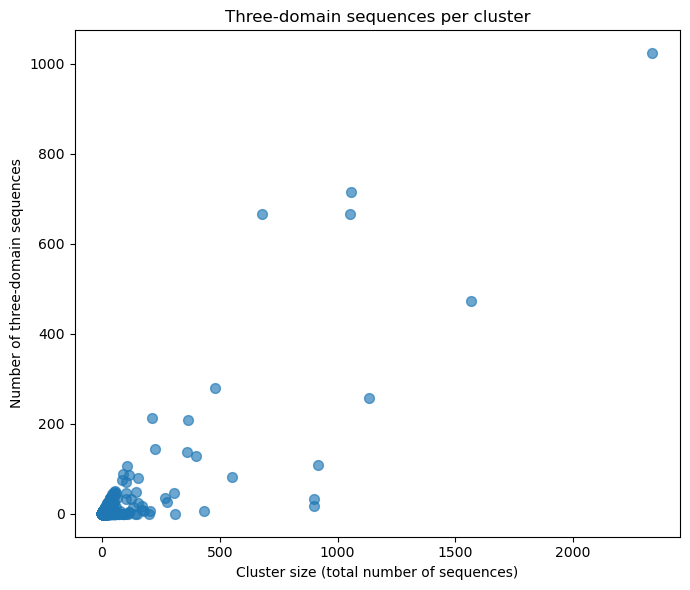

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the cluster summary dataframe
cluster_df = threeand1_473

# Ensure the plotted columns are numeric
cluster_df["totalnumseqs"] = pd.to_numeric(
    cluster_df["totalnumseqs"],
    errors="coerce"
)
cluster_df["num_3domain_x"] = pd.to_numeric(
    cluster_df["num_3domain_x"],
    errors="coerce"
)

# Remove rows missing either plotted value
plot_df = cluster_df.dropna(
    subset=["totalnumseqs", "num_3domain_x"]
)

# Plot cluster size against the number of three-domain sequences
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    plot_df["totalnumseqs"],
    plot_df["num_3domain_x"],
    alpha=0.65,
    s=50
)

# Reference line: all sequences in the cluster are three-domain sequences
max_size = plot_df["totalnumseqs"].max()
#ax.plot(
#    [0, max_size],
#    [0, max_size],
#    linestyle="--",
#    linewidth=1,
#    label="100% three-domain"
#)

ax.set_xlabel("Cluster size (total number of sequences)")
ax.set_ylabel("Number of three-domain sequences")
ax.set_title("Three-domain sequences per cluster")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('../output/cluster_3domaincounts/summary_clustsivevnothreedom.png',dpi=1200)
plt.show()

In [30]:
cluster_df 

,clusterid,totalnumseqs_x,num_3domain_x,prop_of_3dom,totalnumseqs_y,num_3domain_y
0,0.0,2337,1023,10.771823,2337,770
1,1.0,1567,472,4.969991,1567,630
2,10.0,479,279,2.937770,479,3
3,100.0,41,0,0.000000,41,37
4,1000.0,3,0,0.000000,3,3
...,...,...,...,...,...,...
6976,993.0,3,0,0.000000,3,1
6977,994.0,3,0,0.000000,3,0
6978,995.0,3,0,0.000000,3,0
6979,997.0,3,0,0.000000,3,2


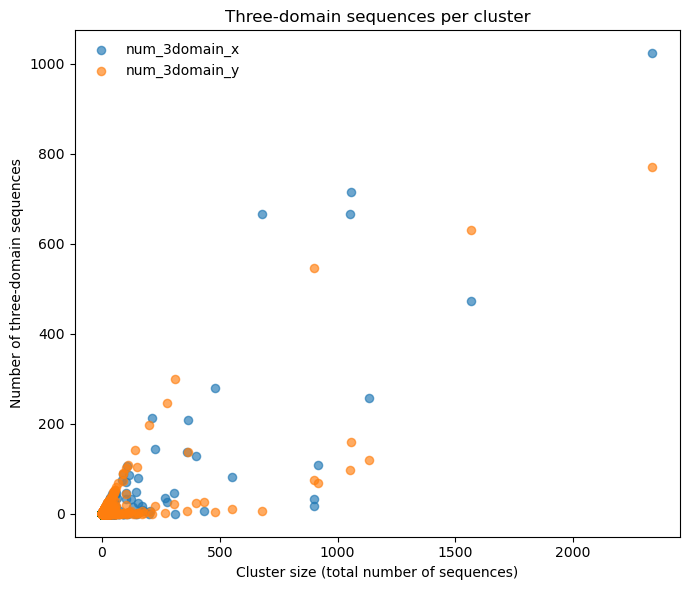

In [42]:
cluster_df = threeand1_473
# Ensure plotted columns are numeric
cols = ["totalnumseqs_x", "num_3domain_x", "num_3domain_y"]
cluster_df[cols] = cluster_df[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

plot_df = cluster_df.dropna(subset=cols)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    plot_df["totalnumseqs_x"],
    plot_df["num_3domain_x"],
    label="num_3domain_x",
    alpha=0.65,
    s=35,
    color="tab:blue"
)

ax.scatter(
    plot_df["totalnumseqs_x"],
    plot_df["num_3domain_y"],
    label="num_3domain_y",
    alpha=0.65,
    s=35,
    color="tab:orange"
)

ax.set_xlabel("Cluster size (total number of sequences)")
ax.set_ylabel("Number of three-domain sequences")
ax.set_title("Three-domain sequences per cluster")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('../output/cluster_3domaincounts/summary_clustsivevnothreedom_and1dom.png',dpi=1200)

plt.show()

In [47]:
threeand1_473.to_csv('../output/cluster_3domaincounts/summary_clusts_size_v_no1and3dom.csv')

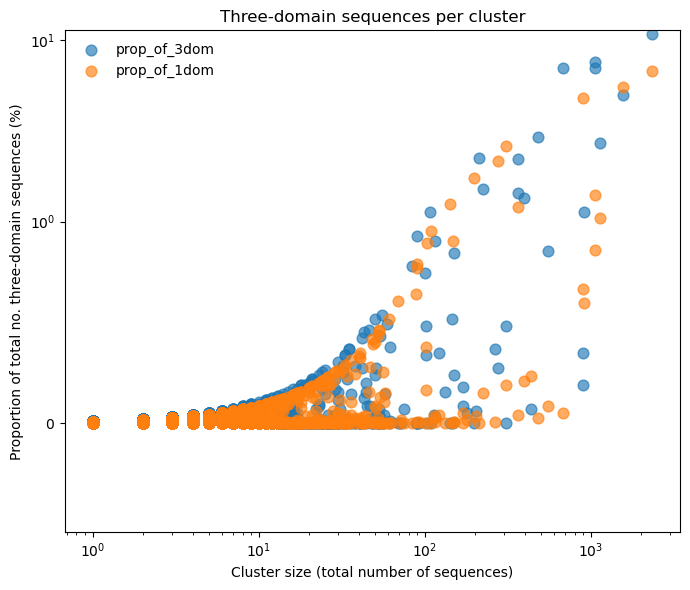

In [46]:
cluster_df = threeand1_473
# Ensure plotted columns are numeric
cols = ["totalnumseqs_x", "prop_of_3dom", "prop_of_1dom"]
cluster_df[cols] = cluster_df[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

plot_df = cluster_df.dropna(subset=cols)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    plot_df["totalnumseqs_x"],
    plot_df["prop_of_3dom"],
    label="prop_of_3dom",
    alpha=0.65,
    s=60,
    color="tab:blue"
)

ax.scatter(
    plot_df["totalnumseqs_x"],
    plot_df["prop_of_1dom"],
    label="prop_of_1dom",
    alpha=0.65,
    s=60,
    color="tab:orange"
)

ax.set_xlabel("Cluster size (total number of sequences)")
ax.set_ylabel("Proportion of total no. three-domain sequences (%)")
ax.set_title("Three-domain sequences per cluster")
ax.legend(frameon=False)
ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=1)
plt.tight_layout()
#plt.savefig('../output/cluster_3domaincounts/summary_clustsivevprop3and1dom.png',dpi=1200)

plt.show()

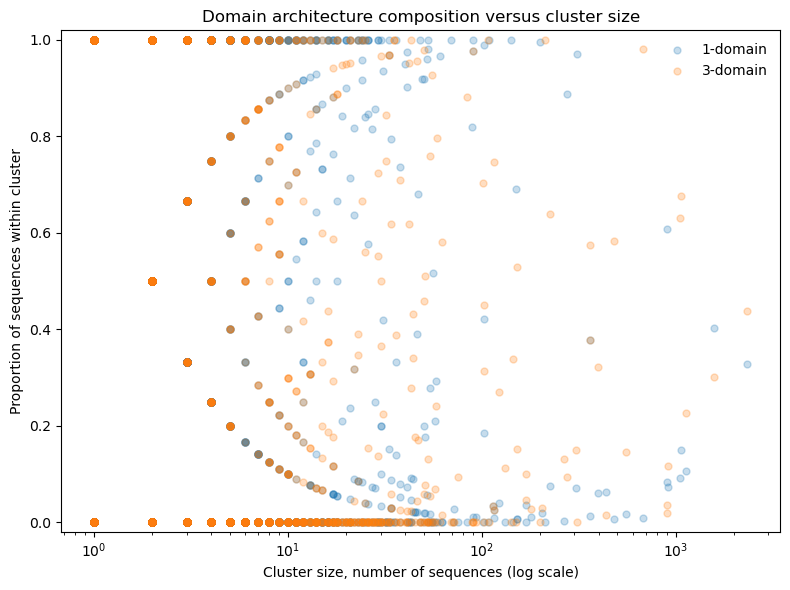

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Rename confusing merged columns first
plot_df = threeand1_473.rename(columns={
    "num_3domain_x": "num_3domain",
    "num_3domain_y": "num_1domain",
    "totalnumseqs_x": "totalnumseqs"
}).copy()

# Calculate proportions within each cluster
plot_df["prop_3domain"] = (
    plot_df["num_3domain"] / plot_df["totalnumseqs"]
)

plot_df["prop_1domain"] = (
    plot_df["num_1domain"] / plot_df["totalnumseqs"]
)

# Remove invalid rows
plot_df = plot_df.loc[
    plot_df["totalnumseqs"].gt(0)
].dropna(
    subset=["totalnumseqs", "prop_3domain", "prop_1domain"]
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    plot_df["totalnumseqs"],
    plot_df["prop_1domain"],
    alpha=0.25,
    s=25,
    label="1-domain"
)

ax.scatter(
    plot_df["totalnumseqs"],
    plot_df["prop_3domain"],
    alpha=0.25,
    s=25,
    label="3-domain"
)

ax.set_xscale("log")
ax.set_ylim(-0.02, 1.02)

ax.set_xlabel("Cluster size, number of sequences (log scale)")
ax.set_ylabel("Proportion of sequences within cluster")
ax.set_title("Domain architecture composition versus cluster size")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

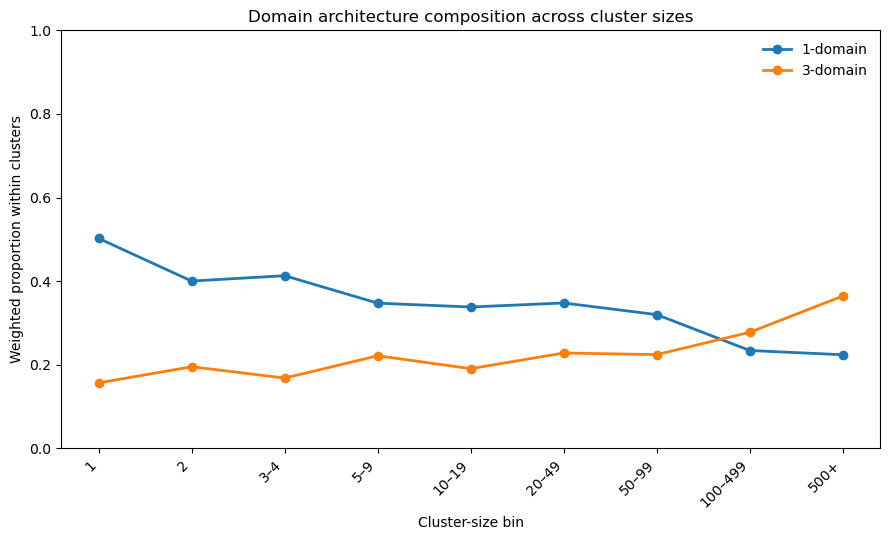

In [50]:
bins = [1, 2, 3, 5, 10, 20, 50, 100, 500, np.inf]
labels = [
    "1", "2", "3–4", "5–9", "10–19",
    "20–49", "50–99", "100–499", "500+"
]

plot_df["size_bin"] = pd.cut(
    plot_df["totalnumseqs"],
    bins=bins,
    labels=labels,
    right=False
)

# Weighted proportions:
# total architecture count across clusters divided by total sequences
binned = (
    plot_df.groupby("size_bin", observed=True)
    .agg(
        total_sequences=("totalnumseqs", "sum"),
        total_1domain=("num_1domain", "sum"),
        total_3domain=("num_3domain", "sum")
    )
    .reset_index()
)

binned["prop_1domain"] = (
    binned["total_1domain"] / binned["total_sequences"]
)

binned["prop_3domain"] = (
    binned["total_3domain"] / binned["total_sequences"]
)

x = np.arange(len(binned))

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(
    x,
    binned["prop_1domain"],
    marker="o",
    linewidth=2,
    label="1-domain"
)

ax.plot(
    x,
    binned["prop_3domain"],
    marker="o",
    linewidth=2,
    label="3-domain"
)

ax.set_xticks(x)
ax.set_xticklabels(binned["size_bin"], rotation=45, ha="right")
ax.set_ylim(0, 1)

ax.set_xlabel("Cluster-size bin")
ax.set_ylabel("Weighted proportion within clusters")
ax.set_title("Domain architecture composition across cluster sizes")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('../output/cluster_3domaincounts/binned_clustersizes_weightedproption.png',dpi=1200)
plt.show()